In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

quarterly = pd.read_csv('../data/processed/quarterly_level_clean.csv')
quarterly['quarter_end'] = pd.to_datetime(quarterly['quarter_end'])
quarterly.head()

,day_of_week,quarter_end,tech_era,patent_count,patent_unique,utility_share,design_share,avg_title_words,avg_keyword_score,kw_5g_count,...,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,year_patent_count,year,quarter
0,1,1976-03-31,legacy_pre_1990,10,10,1.0,0.0,9.000000,0.900000,0,...,347.75,337.375,0.023873,0.074324,10,5.0,0,36,1976,1
1,1,1976-06-30,legacy_pre_1990,5,5,1.0,0.0,8.600000,0.800000,0,...,347.75,337.375,-0.500000,0.074324,5,11.0,0,36,1976,2
2,1,1976-09-30,legacy_pre_1990,11,11,1.0,0.0,8.272727,0.363636,0,...,347.75,337.375,1.200000,0.074324,11,10.0,0,36,1976,3
3,1,1976-12-31,legacy_pre_1990,10,10,1.0,0.0,9.500000,0.300000,0,...,9.00,337.375,-0.090909,0.074324,10,10.0,0,36,1976,4
4,1,1977-03-31,legacy_pre_1990,10,10,0.9,0.1,5.200000,0.100000,0,...,9.00,337.375,0.000000,0.000000,10,9.0,1,42,1977,1


In [4]:
quarterly['period'] = pd.PeriodIndex(year=quarterly['year'], quarter=quarterly['quarter'], freq='Q')
quarterly[['year', 'quarter', 'period']].head()

C:\Users\Pc\AppData\Local\Temp\ipykernel_14636\255807220.py:1: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  quarterly['period'] = pd.PeriodIndex(year=quarterly['year'], quarter=quarterly['quarter'], freq='Q')


,year,quarter,period
0,1976,1,1976Q1
1,1976,2,1976Q2
2,1976,3,1976Q3
3,1976,4,1976Q4
4,1977,1,1977Q1


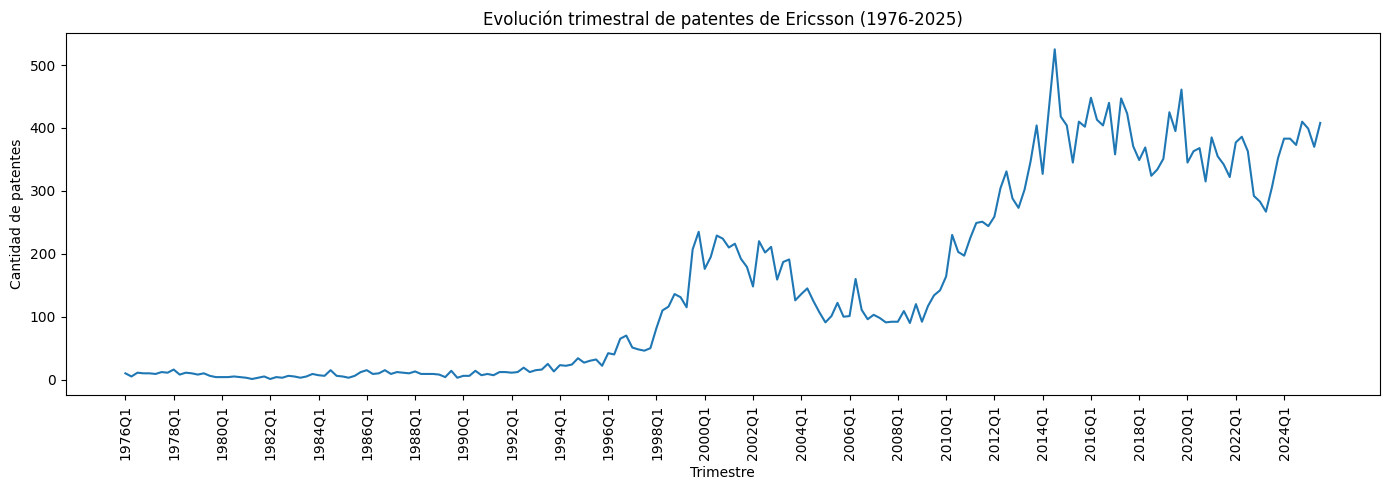

In [9]:
#evolución completa del patent_count en el tiempo
plt.figure(figsize=(14, 5))
plt.plot(quarterly['period'].astype(str), quarterly['patent_count'])
plt.xticks(rotation=90)
plt.title('Evolución trimestral de patentes de Ericsson (1976-2025)')
plt.xlabel('Trimestre')
plt.ylabel('Cantidad de patentes')

# Con 199 trimestres, mostrar todas las etiquetas del eje X sería ilegible,
# así que mostramos solo 1 de cada 8
plt.gca().set_xticks(plt.gca().get_xticks()[::8])

plt.tight_layout()
plt.show()

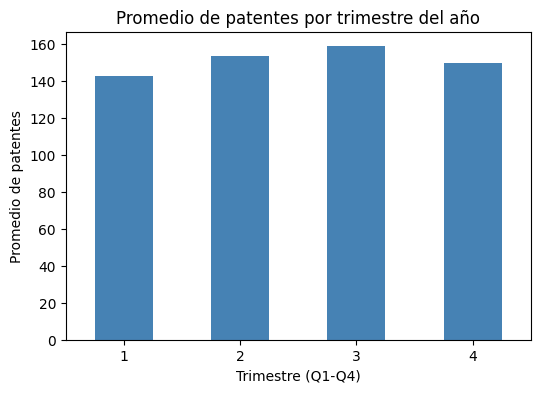

In [2]:
#¿Hay estacionalidad?
estacionalidad = quarterly.groupby('quarter')['patent_count'].mean()

plt.figure(figsize=(6, 4))
estacionalidad.plot(kind='bar', color='steelblue')
plt.title('Promedio de patentes por trimestre del año')
plt.xlabel('Trimestre (Q1-Q4)')
plt.ylabel('Promedio de patentes')
plt.xticks(rotation=0)
plt.show()

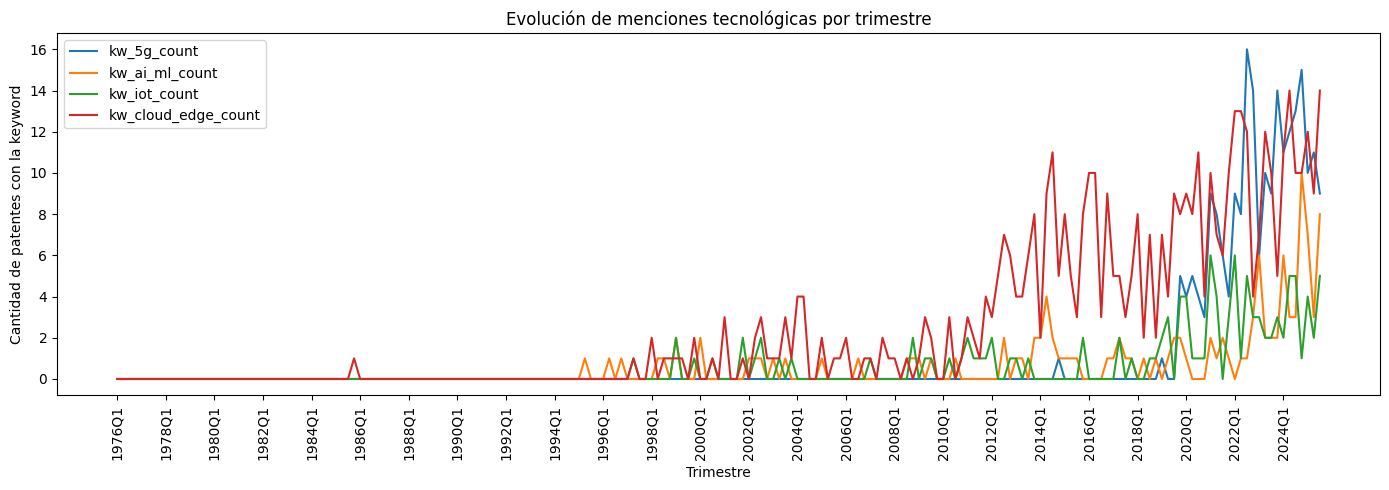

In [5]:
#¿Cuándo despegó cada tecnología?
kw_cols = ['kw_5g_count', 'kw_ai_ml_count', 'kw_iot_count', 'kw_cloud_edge_count']

plt.figure(figsize=(14, 5))
for col in kw_cols:
    plt.plot(quarterly['period'].astype(str), quarterly[col], label=col)

plt.xticks(rotation=90)
plt.gca().set_xticks(plt.gca().get_xticks()[::8])
plt.title('Evolución de menciones tecnológicas por trimestre')
plt.xlabel('Trimestre')
plt.ylabel('Cantidad de patentes con la keyword')
plt.legend()
plt.tight_layout()
plt.show()

patent_type
utility    29694
design       376
reissue       48
Name: count, dtype: int64


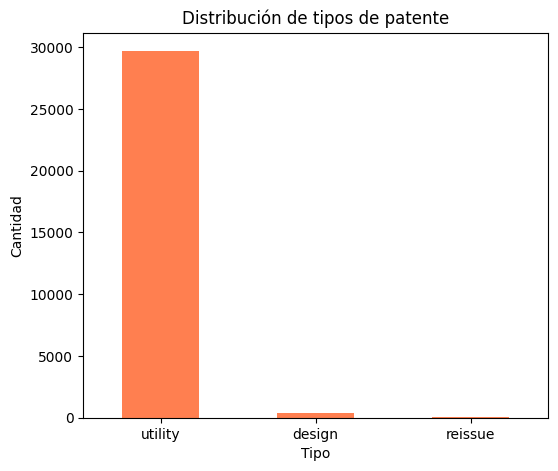

In [6]:
#Distribución de patent_type
patent = pd.read_csv('../data/processed/patent_level_clean.csv')

conteo_tipos = patent['patent_type'].value_counts()
print(conteo_tipos)

plt.figure(figsize=(6, 5))
conteo_tipos.plot(kind='bar', color='coral')
plt.title('Distribución de tipos de patente')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

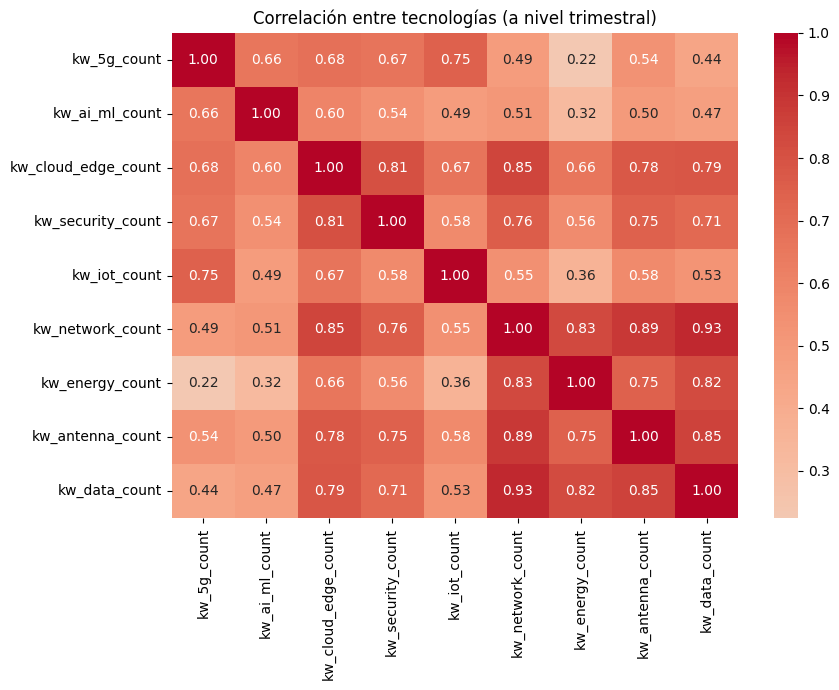

In [7]:
#Heatmap de correlación entre keywords
kw_cols_heatmap = ['kw_5g_count', 'kw_ai_ml_count', 'kw_cloud_edge_count', 
                     'kw_security_count', 'kw_iot_count', 'kw_network_count',
                     'kw_energy_count', 'kw_antenna_count', 'kw_data_count']

corr_matrix = quarterly[kw_cols_heatmap].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre tecnologías (a nivel trimestral)')
plt.tight_layout()
plt.show()

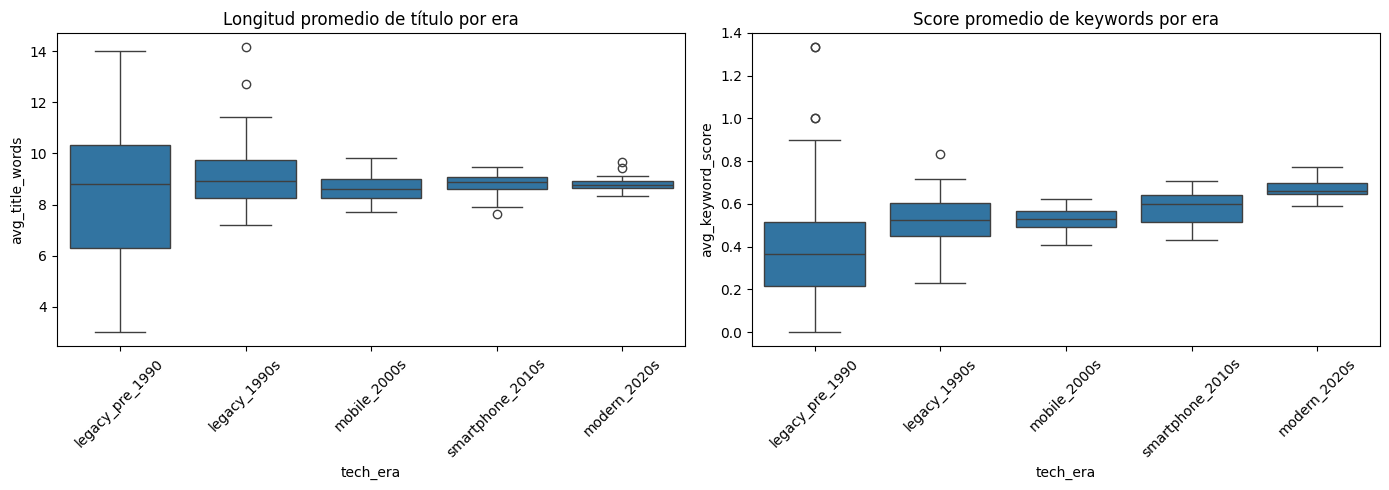

In [8]:
#avg_title_words y keyword_score por tech_era
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=quarterly, x='tech_era', y='avg_title_words', ax=axes[0])
axes[0].set_title('Longitud promedio de título por era')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=quarterly, x='tech_era', y='avg_keyword_score', ax=axes[1])
axes[1].set_title('Score promedio de keywords por era')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1. Evolución del volumen de patentes (1976-2025)

La actividad de patentamiento de Ericsson no fue lineal, sino que muestra dos grandes ciclos de innovación separados por una fase de estancamiento:

1976-1996: actividad baja y estable (5-30 patentes/trimestre), correspondiente a la era pre-móvil.
1997-2003: primer boom, con un pico de ~250 patentes/trimestre alrededor de 2000-2001, coincidiendo con la explosión de la telefonía móvil GSM (2G/3G).
2004-2010: caída pronunciada y estancamiento en ~100 patentes/trimestre, reflejando probablemente la crisis de las puntocom y la reestructuración de la industria de telecom.
2011-2025: segundo boom, mucho más intenso, con un pico superior a 500 patentes/trimestre en 2014-2015 y niveles sostenidos altos (300-450) hasta 2025. Coincide con la era de smartphones, 4G/5G, IoT y AI.

Conclusión: la innovación de Ericsson está fuertemente ligada a revoluciones tecnológicas específicas del sector telecom, no a un crecimiento orgánico constante.

2. ¿Existe estacionalidad?

El promedio de patentes por trimestre (Q1-Q4) es bastante parejo, oscilando entre 140 y 160 patentes, con Q3 levemente superior. No hay una estacionalidad fuerte dentro del año — a diferencia de industrias como retail (con picos en Q4 por navidad), la actividad de I+D e innovación de Ericsson se mantiene relativamente constante mes a mes.

3. Evolución de tecnologías clave (5G, AI/ML, IoT, Cloud)
Todas las tecnologías analizadas están en cero hasta mediados de los años 90, lo cual es esperable ya que aún no existían.
Cloud/Edge fue la primera en despegar, iniciando su crecimiento alrededor de 2000-2004 y manteniéndose como la más constante a lo largo del tiempo.
5G, AI/ML e IoT arrancan más tarde (~2012-2014) y muestran un crecimiento explosivo a partir de 2020-2022, con alta volatilidad trimestre a trimestre.
El pico máximo de menciones tecnológicas de toda la serie se concentra entre 2022 y 2024.

Conclusión: la última década (2015-2025) concentra la explosión de innovación en 5G, AI/ML e IoT, coincidiendo con la era modern_2020s del dataset.

4. Distribución por tipo de patente
Tipo	Cantidad	%
utility	29,694	98.6%
design	376	1.2%
reissue	48	0.2%

Conclusión: el dataset está extremadamente dominado por patentes tipo "utility". Esto significa que, para efectos prácticos, cualquier análisis o modelo posterior puede tratar el dataset como si fuera "solo utility" sin perder representatividad — design y reissue son casos anecdóticos, no dan para un análisis segmentado por tipo.

5. Correlación entre tecnologías

El heatmap revela dos patrones claros:

Un cluster fuertemente correlacionado: network, energy, antenna y data presentan correlaciones muy altas entre sí (0.75-0.93). Tiene sentido: son tecnologías de infraestructura de telecomunicaciones que avanzan de manera conjunta — una patente de antena suele también tocar temas de red y datos.
AI/ML como caso más independiente: presenta correlaciones notablemente más bajas con el resto (0.32-0.66), sugiriendo que su desarrollo siguió una trayectoria propia, menos atada al stack tradicional de telecom.

Conclusión: existe un "núcleo duro" de infraestructura de red que evoluciona junta, mientras que AI/ML representa un frente de innovación más autónomo dentro del portafolio de Ericsson.

6. Complejidad de títulos y densidad de keywords por era
avg_title_words: se mantiene relativamente estable entre eras (8-11 palabras en promedio), con algo más de dispersión en legacy_pre_1990. No hay una tendencia clara de títulos más largos con el tiempo.
avg_keyword_score: muestra una tendencia clara y creciente, pasando de ~4 en legacy_pre_1990 a ~6.5-7 en modern_2020s.

Conclusión: aunque los títulos no se alargaron significativamente, sí aumentó la densidad de términos tecnológicos por patente. Esto refleja la convergencia tecnológica: una patente moderna de 5G frecuentemente también menciona IoT, cloud, security, etc., algo mucho menos común en patentes de décadas anteriores donde cada invención estaba más aislada tecnológicamente.

Conclusiones generales EDA
-La innovación de Ericsson siguió un patrón de dos ciclos de boom (2000 y 2012+) separados por un período de estancamiento, en vez de un crecimiento lineal.
-No existe estacionalidad relevante dentro del año — el patentamiento es constante trimestre a trimestre.
-Cloud/Edge lideró la adopción tecnológica temprana, mientras que 5G, AI/ML e IoT explotaron recién en la última década.
-El dataset está dominado casi por completo por patentes "utility" (98.6%).
-Existe un cluster de tecnologías de infraestructura altamente correlacionadas (network/energy/antenna/data), mientras que AI/ML se comporta de forma más independiente.
-La densidad de keywords tecnológicos por patente aumentó con el tiempo, evidenciando una creciente convergencia entre distintas tecnologías dentro de una misma invención.